In [ ]:
import polars as pl

df = (
    pl.scan_parquet(r"C:\Users\ben.hardcastle\Downloads\spike_counts.parquet")
    .head(1000)
    .collect()
)
df

trial_index,unit_id,baseline,response
i64,str,i64,i64
0,"""626791_2022-08-16_A-22""",0,0
1,"""626791_2022-08-16_A-22""",0,1
2,"""626791_2022-08-16_A-22""",0,1
3,"""626791_2022-08-16_A-22""",0,0
4,"""626791_2022-08-16_A-22""",2,0
…,…,…,…
495,"""626791_2022-08-16_A-24""",0,0
496,"""626791_2022-08-16_A-24""",0,0
497,"""626791_2022-08-16_A-24""",0,0


In [43]:
import polars as pl

df = (
    pl.scan_parquet(r"C:\Users\ben.hardcastle\Downloads\spike_counts.parquet")
    .head(100_000)
    .with_columns(
        session_id=pl.col('unit_id').str.split('_').list.slice(0, 2).list.join('_'),
    )
    # get spike-count / time correlation values ------------------------ #
    # .join(
    #     other=pl.scan_parquet("//allen/programs/mindscope/workgroups/dynamicrouting/ben/corr_values.parquet"),
    #     on='unit_id',
    #     how='inner',
    # )
    # get annotations -------------------------------------------------- #
    # .join(
    #     other=(
    #         pl.scan_parquet("//allen/programs/mindscope/workgroups/dynamicrouting/ben/unit_drift.parquet")
    #         .select('unit_id', 'drift_rating')
    #         .filter(
    #             pl.col('drift_rating') != 5,
    #         )
    #     ),
    #     on='unit_id',
    #     how='left',
    # )
    # get unit metrics from sorting ------------------------------------ #
    # .join(
    #     other=(
    #         pl.scan_parquet("s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.261/consolidated/units.parquet")
    #         .select('unit_id', 'presence_ratio')
    #     ),
    #     on='unit_id',
    #     how='left',
    # )
    # get trial metadata ----------------------------------------------- #
    .join(
        other=(
            pl.scan_parquet("s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.261/consolidated/trials.parquet")
            .select('session_id', 'trial_index', 'block_index', 'context_name')
        ),
        on=['session_id', 'trial_index',],
        how='inner',
    )
    # aggregate spike counts by block ---------------------------------- #
    # .group_by(gb_cols := ['unit_id', 'block_index', 'context_name'])
    # .agg(
    #     pl.all().exclude('baseline', 'response'),
    #     pl.col('baseline').median(),
    #     pl.col('response').median(),
    # )
    # .explode(pl.all().exclude(*gb_cols, 'baseline', 'response'))
    # discard trial info ----------------------------------------------- #
    # .drop('trial_index')
    # .group_by('unit_id', 'block_index').agg(pl.all()).explode(pl.all().exclude('unit_id', 'block_index'))
    # ------------------------------------------------------------------ #
    .collect(streaming=False)
)
df

trial_index,unit_id,baseline,response,session_id,block_index,context_name
i64,str,i64,i64,str,i64,str
0,"""626791_2022-08-16_A-22""",0,0,"""626791_2022-08-16""",0,"""aud"""
0,"""626791_2022-08-16_A-24""",0,0,"""626791_2022-08-16""",0,"""aud"""
0,"""626791_2022-08-16_A-23""",10,42,"""626791_2022-08-16""",0,"""aud"""
0,"""626791_2022-08-16_A-27""",0,1,"""626791_2022-08-16""",0,"""aud"""
0,"""626791_2022-08-16_A-21""",4,2,"""626791_2022-08-16""",0,"""aud"""
…,…,…,…,…,…,…
499,"""626791_2022-08-16_C-8""",1,1,"""626791_2022-08-16""",5,"""vis"""
499,"""626791_2022-08-16_C-7""",35,56,"""626791_2022-08-16""",5,"""vis"""
499,"""626791_2022-08-16_C-6""",0,0,"""626791_2022-08-16""",5,"""vis"""


In [15]:
import polars as pl

old = pl.scan_parquet("s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.265/consolidated/session.parquet")
new = pl.scan_parquet("s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.268/consolidated/session.parquet")

x = []
for df in (old, new):
    x.append(df.filter(pl.col('keywords').list.contains('ccf') & pl.col('keywords').list.contains('production')).unique('session_id').collect())
set(x[1]['session_id']) - set(x[0]['session_id'])

{'744279_2025-01-13',
 '744279_2025-01-14',
 '744279_2025-01-15',
 '744279_2025-01-16',
 '746439_2025-01-27',
 '746439_2025-01-28',
 '746439_2025-01-29',
 '746439_2025-01-30',
 '746439_2025-01-31',
 '759434_2025-02-03',
 '759434_2025-02-04',
 '759434_2025-02-05',
 '759434_2025-02-06',
 '759434_2025-02-07'}

In [3]:
import pickle
import upath

f = pickle.loads(upath.UPath('s3://aind-scratch-data/dynamic-routing/encoding/results/fullmodel_pkl_files/v268_0/626791_2022-08-15.pkl').read_bytes())


In [15]:
import polars as pl

pl.scan_parquet(
    next(upath.UPath('s3://aind-scratch-data/dynamic-routing/encoding/results/v268_0').glob('*fullmodel.parquet'))
).collect_schema()

Schema([('session_id', String),
        ('unit_id', String),
        ('project', String),
        ('cv_test', Float64),
        ('cv_train', Float64),
        ('weights', List(Float64)),
        ('dropped_variable', String),
        ('shift_index', Int32),
        ('model_label', String)])

In [21]:
sorted(f['run_params'].keys())

['L1_fixed_lambda',
 'L1_grid_num',
 'L1_grid_range',
 'L1_grid_type',
 'L1_ratio_fixed',
 'L1_ratio_grid_num',
 'L1_ratio_grid_range',
 'L1_ratio_grid_type',
 'L2_fixed_lambda',
 'L2_grid_num',
 'L2_grid_range',
 'L2_grid_type',
 'areas_to_exclude',
 'areas_to_include',
 'cell_L1_ratio',
 'cell_L1_ratio_nested',
 'cell_rank',
 'cell_rank_nested',
 'cell_regularization',
 'cell_regularization_nested',
 'datacube_version',
 'decoder_labels_to_exclude',
 'fullmodel_fitted',
 'half_gaussian_std_dev',
 'input_offsets',
 'input_variables',
 'input_window_lengths',
 'intercept',
 'kernels',
 'linear_shift_by',
 'linear_shift_variables',
 'method',
 'model_label',
 'n_inner_folds',
 'n_outer_folds',
 'no_nested_CV',
 'num_rate_clusters',
 'optimize_on',
 'optimize_penalty_by_area',
 'optimize_penalty_by_cell',
 'optimize_penalty_by_firing_rate',
 'orthogonalize_against_context',
 'presence_ratio',
 'project',
 'rank_fixed',
 'rank_grid_num',
 'result_prefix',
 'reuse_regularization_coefficien

In [27]:
(
    pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.265/consolidated/units.parquet')
    .filter(
        pl.col('session_id') == '742903_2024-10-22',
        pl.col('activity_drift') <= 0.2,
        pl.col('decoder_label') != "noise",
        (pl.col('isi_violations_ratio') <= 0.5) & (pl.col('amplitude_cutoff') <= 0.1) & (pl.col('presence_ratio') >= 0.7),
    )
    .collect()
)['structure'].value_counts()

structure,count
str,u32
"""PL""",55
"""ACAd""",67
"""LSr""",47
"""LGv""",1
"""ILA""",176
…,…
"""CP""",102
"""SSs""",119
"""VISal""",20


In [ ]:
- number of mice (prod ephys, annotated): 
- number of sessions 
- number of insertions 
- number of areas recorded in at least 5 sessions 

In [ ]:
sessions = (
    pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/session_metadata/session_table.parquet')
    .filter(
        'is_production', 
        'is_annotated', 
        ~pl.col('is_opto_perturbation'),            # -6 sessions
        ~pl.col('is_injection_perturbation'),       # -0 sessions
        pl.col('issues').list.len() == 0,         # -10 sesisons 
    )
    .collect()
)


173

In [79]:
metrics = {}

sessions = (
    pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/session_metadata/session_table.parquet')
    .filter(
        'is_production', 
        'is_annotated', 
        ~pl.col('is_opto_perturbation'),            # -6 sessions
        ~pl.col('is_injection_perturbation'),       # -0 sessions
        pl.col('issues').list.len() == 0,           # -10 sesisons 
    )
    .collect()
)
metrics['ephys sessions (prod, annotated, no issues)'] = sessions['session_id'].n_unique()
metrics['mice'] = sessions['subject_id'].n_unique()

units = (
    pl.scan_parquet(
        's3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.268/consolidated/units.parquet'
    )
    .filter(
        pl.col('session_id').is_in(sessions['session_id']),
    )
    .collect()
)
metrics['total insertions (in sessions above)'] = len(units.unique(['session_id', 'electrode_group_name']))
metrics['areas (recorded in at least 5 sessions)'] = units.filter(pl.col('session_id').n_unique().ge(5).over('structure'))['structure'].n_unique()
metrics

C:\Users\ben.hardcastle\AppData\Local\Temp\ipykernel_22304\3486773843.py:24: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .collect()


{'ephys sessions (prod, annotated, no issues)': 173,
 'mice': 53,
 'total insertions (in sessions above)': 849,
 'areas (recorded in at least 5 sessions)': 145}

In [109]:
df = pl.scan_parquet(
    's3://aind-scratch-data/dynamic-routing/decoding/results/time_mod_20250502_062638/'
).drop(['unit_ids', 'predict_proba', 'electrode_group_names']).collect()

In [115]:
df['bin_center'].value_counts().sort('bin_center').describe()
# df['time_aligned_to'].value_counts()

statistic,bin_center,count
str,f64,f64
"""count""",13.0,13.0
"""null_count""",0.0,0.0
"""mean""",0.9,59850.0
"""std""",0.778888,0.0
"""min""",-0.3,59850.0
"""25%""",0.3,59850.0
"""50%""",0.9,59850.0
"""75%""",1.5,59850.0
"""max""",2.1,59850.0


In [11]:
import numpy as np  
np.logspace(1, 3, num=3, endpoint=True)

array([  10.,  100., 1000.])

In [20]:
import os
os.cpu_count()

16

In [26]:
np.uint64(2)

np.uint64(2)

In [ ]:
[10**i for i in range(1, 4)]

[10, 100, 1000]

In [15]:
import upath
for p in upath.UPath('s3://aind-scratch-data/ben.hardcastle/num_threads_benchmark/').glob('*'):
    p.unlink()


In [ ]:
df = (
    pl.scan_parquet(f's3://aind-scratch-data/ben.hardcastle/num_threads_benchmark/')
    .filter(pl.col('library_benchmark') == 'openblas')
    .collect()
)

In [ ]:
df.with_columns(
    # normalize wall time to value when nthreads == num cpu cores
    norm=(pl.col('wall_time') / pl.col('wall_time').filter(pl.col('OPENBLAS_NUM_THREADS') == pl.col('co_cpus')).first()),
)

OPENBLAS_NUM_THREADS,MKL_NUM_THREADS,library_benchmark,wall_time,os_cpus,co_cpus,matrix_size,norm
u16,u16,enum,f64,i64,i64,i64,f64
11,7,"""openblas""",0.000001,16,1,10,0.62
4,3,"""openblas""",0.000001,16,1,10,0.62
9,11,"""openblas""",0.000001,16,1,10,0.62
null,null,"""openblas""",0.000001,16,1,10,0.62
12,14,"""openblas""",0.000002,16,1,10,0.64
…,…,…,…,…,…,…,…
2,7,"""openblas""",0.000062,16,1,100,25.839999
9,5,"""openblas""",0.000063,16,1,100,26.239999
8,15,"""openblas""",0.000064,16,1,100,26.979999


In [136]:
df =     pl.read_parquet(f's3://aind-scratch-data/ben.hardcastle/num_threads_benchmark/')

In [138]:
import altair as alt    
import polars as pl 

def norm_time()  -> pl.Expr:
    over_cols = ['is_pipeline', 'library benchmarked', 'co cpu count', 'os cpu count', 'matrix size']
    # normalize wall time to value when nthreads == num cpu cores available
    return (
        pl.when(pl.col('library benchmarked') == 'openblas')
        .then(
            (pl.col('wall time') / pl.col('wall time').filter(pl.col('OPENBLAS_NUM_THREADS') == pl.col('co cpu count')).first()).over(over_cols)
        )
        .when(pl.col('library benchmarked') == 'mkl')
        .then(
            (pl.col('wall time') / pl.col('wall time').filter(pl.col('MKL_NUM_THREADS') == pl.col('co cpu count')).first()).over(over_cols)
        )
        .otherwise(pl.lit(None))
    )
    
(
    df
    .filter(
        pl.col('library benchmarked') == 'openblas',
    )
    .with_columns(
        norm_time().alias('normalized time'),
    )
    .plot.rect(
        x='OPENBLAS_NUM_THREADS:O',
        y=alt.Y('co cpu count:O').scale(reverse=True),
        color=alt.Color('normalized time:Q').scale(scheme="redblue", domainMid=0, reverse=True),
        column='matrix size:O',
        detail='os cpu count:O',
        row='is_pipeline',
    )
)

alt.Chart(...)

In [133]:
(
    df
    .filter(
        pl.col('library benchmarked') == 'openblas',
    )
    .with_columns(
        norm_time().alias('normalized time'),
    )
    .plot.line(
        x='OPENBLAS_NUM_THREADS:O',
        y='normalized time:Q',
        color='co cpu count:O',
        # color=alt.Color('normalized time:Q').scale(scheme="redblue", domainMid=0, reverse=True),
        column='matrix size:O',
        detail='os cpu count:O',
        row='is_pipeline',
    )
)

alt.Chart(...)

In [ ]:
import altair as alt    
import polars as pl 

(
    pl.read_parquet(f's3://aind-scratch-data/ben.hardcastle/num_threads_benchmark/')
    .plot.rect(
        x='OPENBLAS_NUM_THREADS:O',
        y=alt.Y('co_cpus:O').scale(reverse=True),
        color='wall_time',
        column='benchmark',
    )

)

alt.Chart(...)

In [107]:
df.describe()

statistic,balanced_accuracy_test,time_aligned_to,bin_size,bin_center,shift_idx,repeat_idx,is_all_trials,session_id,structure,unit_subsample_size,unit_criteria
str,f64,str,f64,f64,f64,f64,f64,str,str,f64,str
"""count""",93450.0,"""93450""",93450.0,93450.0,92400.0,93450.0,93450.0,"""93450""","""93450""",93450.0,"""93450"""
"""null_count""",0.0,"""0""",0.0,0.0,1050.0,0.0,0.0,"""0""","""0""",0.0,"""0"""
"""mean""",0.571847,null,0.2,1.1880e-21,0.5,12.0,0.011236,null,null,20.0,null
"""std""",0.059409,null,0.0,0.100001,25.401909,7.211141,null,null,null,0.0,null
"""min""",0.385749,null,0.2,-0.1,-43.0,0.0,0.0,"""742903_2024-10-22""","""ACAd""",20.0,"""loose_drift"""
"""25%""",0.529903,null,0.2,-0.1,-21.0,6.0,null,null,null,20.0,null
"""50%""",0.563188,null,0.2,0.1,1.0,12.0,null,null,null,20.0,null
"""75%""",0.605266,null,0.2,0.1,22.0,18.0,null,null,null,20.0,null
"""max""",0.842705,null,0.2,0.1,44.0,24.0,1.0,"""742903_2024-10-22""","""TTd""",20.0,"""loose_drift"""


In [101]:
sessions.filter(pl.col('subject_genotype').str.to_lowercase().str.contains_any(['sst', 'vip']), pl.col('epochs').list.contains('OptoTagging'))

session_id,is_production,project,date,time,subject_id,subject_age_days,subject_sex,subject_genotype,implant,rig,experimenters,notes,issues,allen_path,cloud_path,task_version,ephys_day,behavior_day,epochs,is_ephys,is_deep_insertions,is_sync,is_video,is_templeton,is_annotated,is_hab,is_task,is_invalid_times,is_naive,is_context_naive,is_late_autorewards,is_spontaneous,is_spontaneous_rewards,is_rf_mapping,is_optotagging,is_optotagging_control,is_opto_perturbation,is_injection_perturbation,is_opto_control,is_injection_control,probe_letters_available,probe_letters_to_skip,probe_letters_annotated,deep_probe_letters_to_skip,areas_perturbed,areas_recorded,task_duration,mean_vis_dprime,mean_aud_dprime,n_passing_blocks,cross_modality_dprime_vis_blocks,cross_modality_dprime_aud_blocks,n_hits,n_contingent_rewards,n_responses,n_trials,is_first_block_aud,is_first_block_vis,is_engaged,is_good_behavior,is_bad_behavior,is_stage_5_passed
str,bool,str,str,str,i64,i64,str,str,str,str,list[str],str,list[str],str,str,str,i64,i64,list[str],bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,str,str,str,list[str],list[str],f64,f64,f64,i64,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],bool,bool,bool,bool,bool,bool
"""660023_2023-08-09""",true,"""DynamicRouting""","""2023-08-09""","""08:09:09""",660023,253,"""F""","""Sst-IRES-Cre/wt;Ai32(RCL-ChR2(…","""2002""","""NP3""","[""Jackie Kuyat""]",null,[],"""//allen/programs/mindscope/wor…","""s3://aind-ephys-data/ecephys_6…","""stage 5 AMN ori moving""",2,78,"[""RFMapping"", ""OptoTagging"", … ""OptoTagging""]",true,true,true,true,false,true,false,true,false,false,false,true,true,true,true,true,false,false,false,false,false,"""ABCDEF""","""""","""ABCDEF""","""""",null,"[""CA1"", ""CA3"", … ""out of brain""]",3621.21838,0.958485,-0.102254,5,"[3.202512, 3.201393, -0.393042]","[2.17941, 1.375637, 1.991971]","[25.0, 20.0, … 13.0]","[25.0, 20.0, … 13.0]","[52.0, 27.0, … 33.0]","[90.0, 76.0, … 78.0]",true,false,true,true,false,false
"""666986_2023-08-14""",true,"""DynamicRouting""","""2023-08-14""","""11:38:55""",666986,200,"""M""","""Sst-IRES-Cre/wt;Ai32(RCL-ChR2(…","""2002""","""NP3""","[""Jackie Kuyat""]",null,[],"""//allen/programs/mindscope/wor…","""s3://aind-ephys-data/ecephys_6…","""stage 5 AMN ori moving""",1,74,"[""RFMapping"", ""RFMapping"", … ""OptoTagging""]",true,false,true,true,false,true,false,true,false,false,false,true,true,true,true,true,false,false,false,false,false,"""ACDEF""","""""","""ACDEF""","""""",null,"[""ACAd"", ""ACAv"", … ""out of brain""]",3636.68152,0.948551,0.374745,5,"[1.151724, 2.193459, 0.728516]","[1.926632, 1.801222, 2.643205]","[22.0, 23.0, … 23.0]","[22.0, 23.0, … 23.0]","[52.0, 50.0, … 46.0]","[74.0, 89.0, … 90.0]",true,false,true,true,false,false
"""666986_2023-08-15""",true,"""DynamicRouting""","""2023-08-15""","""08:13:00""",666986,201,"""M""","""Sst-IRES-Cre/wt;Ai32(RCL-ChR2(…","""2002""","""NP3""","[""Jackie Kuyat""]",null,[],"""//allen/programs/mindscope/wor…","""s3://aind-ephys-data/ecephys_6…","""stage 5 ori AMN moving""",2,75,"[""RFMapping"", ""OptoTagging"", … ""OptoTagging""]",true,false,true,true,false,true,false,true,false,false,false,true,true,true,true,true,false,false,false,false,false,"""ABCDEF""","""""","""ABCDEF""","""""",null,"[""ACAd"", ""ACAv"", … ""out of brain""]",3638.16628,1.482637,0.286511,5,"[2.449813, 0.744254, 1.854548]","[2.036834, 2.89537, 1.711675]","[23.0, 24.0, … 22.0]","[23.0, 24.0, … 22.0]","[36.0, 44.0, … 41.0]","[88.0, 93.0, … 88.0]",false,true,true,true,false,false
"""666986_2023-08-17""",true,"""DynamicRouting""","""2023-08-17""","""14:18:36""",666986,203,"""M""","""Sst-IRES-Cre/wt;Ai32(RCL-ChR2(…","""2002""","""NP3""","[""Jackie Kuyat""]",null,[],"""//allen/programs/mindscope/wor…","""s3://aind-ephys-data/ecephys_6…","""stage 5 ori AMN moving""",4,77,"[""RFMapping"", ""OptoTagging"", … ""OptoTagging""]",true,false,true,true,false,true,false,true,false,false,false,t

In [92]:
np.float64(2**0.5), np.float32(2**0.5)

(np.float64(1.4142135623730951), np.float32(1.4142135))

In [90]:
np.float64(2**0.5) - np.float32(2**0.5)

np.float64(2.4203234305630872e-08)

In [82]:
import numpy as np

np.array_equal(np.array([[0.0,1.0], [2,3]]), np.array([[0,1], [2,3]]))

True

579431

In [ ]:
len(
    units
    .unique(['session_id', 'electrode_group_name'])
)

1186

55 mice
189 sessions

In [ ]:
schema_a = pl.Schema({'a': pl.Int16})
schema_b = pl.Schema({'a': pl.Int32})

pl.DataFrame(schema=schema_a)

SchemaError: type Int32 is incompatible with expected type Int16

In [29]:
df.sort('count')

structure,count
str,u32
"""LGv""",1
"""DG""",2
"""CA3""",7
"""OLF""",11
"""CA1""",14
…,…
"""SSs""",119
"""ILA""",176
"""ORBvl""",254


In [ ]:
import polars as pl

p = next(upath.UPath('s3://aind-scratch-data/dynamic-routing/encoding/results/v268_0').glob('*fullmodel.parquet'))
(
    
    
)

S3Path('s3://aind-scratch-data/dynamic-routing/encoding/results/v268_0/626791_2022-08-15_fullmodel.parquet')

In [ ]:


# def get_passing_blocks_performance_filter(
cross_modality_dprime_threshold: float | None = 1.0
rewarded_modality_dprime_threshold: float | None = None
min_n_blocks: int = 4
of_each_rewarded_modality: bool = False
min_trials: int | None = 10
min_contingent_rewards: int | None = 10
rewarded_modality_dprime: pl.Expr = (
    pl.when(pl.col('rewarded_modality') == 'vis').then(pl.col('vis_dprime')).otherwise(pl.col('aud_dprime'))
)
unrewarded_modality_dprime: pl.Expr = (
    pl.when(pl.col('rewarded_modality') == 'vis').then(pl.col('aud_dprime')).otherwise(pl.col('vis_dprime'))
)
cross_modality_dprime_filter: pl.Expr = (
    (pl.col("cross_modality_dprime") > cross_modality_dprime_threshold)
    if cross_modality_dprime_threshold is not None
    else pl.lit(True)
)
rewarded_modality_dprime_filter: pl.Expr = (
    (rewarded_modality_dprime > rewarded_modality_dprime_threshold)
    if rewarded_modality_dprime_threshold is not None
    else pl.lit(True)
)
min_n_trials_filter: pl.Expr = (
    (pl.col("n_trials") > min_trials)
    if min_trials is not None
    else pl.lit(True)
)
min_n_responses_filter: pl.Expr = (
    (pl.col("n_responses") > min_contingent_rewards)
    if min_contingent_rewards is not None
    else pl.lit(True)
)
n_blocks_each_context: pl.Expr = (
    pl.col("rewarded_modality")
    .filter(
        cross_modality_dprime_filter,
        # rewarded_modality_dprime_filter,
        min_n_trials_filter,
        min_n_responses_filter,
    )
    .unique_counts()
    .over("session_id", mapping_strategy="join")
)
if of_each_rewarded_modality:
    # at least n_blocks of each context, and two contexts:
    expr = (
        (n_blocks_each_context.list.eval(pl.element() >= min_n_blocks).list.all())
        & (n_blocks_each_context.list.len() == 2)
    )
else:
    # at least n_blocks of any context:
    expr = (
        n_blocks_each_context.list.sum()
        >= min_n_blocks
    )

old_sessions = (
    old.with_columns(expr.alias('expr')).filter(pl.col('expr').eq(True)).collect()['session_id']
)
new_sessions = (
    new.with_columns(expr.alias('expr')).filter(pl.col('expr').eq(True)).collect()['session_id']
)
set(old_sessions) - set(new_sessions), set(new_sessions) - set(old_sessions)

({'708016_2024-05-02',
  '726088_2024-06-21',
  '733780_2024-08-29',
  '736208_2024-09-03'},
 {'644866_2023-02-07',
  '712141_2024-06-06',
  '712141_2024-06-13',
  '715706_2024-06-27',
  '733891_2024-09-20'})

In [94]:
import polars as pl

old = (
    pl.scan_parquet("s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.265/consolidated/performance.parquet")
    .rename(
        {
            'cross_modal_dprime': 'cross_modality_dprime',
            'signed_cross_modal_dprime': 'signed_cross_modality_dprime',
            'vis_intra_dprime': 'vis_dprime',
            'aud_intra_dprime': 'aud_dprime',
            # 'n_trials': 'n_trials_in_block',
            # 'n_responses': 'n_responses_in_block',
        }
    )
    .drop('same_modal_dprime', 'nonrewarded_modal_dprime')
)
new = pl.scan_parquet("s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.268/consolidated/performance.parquet")

old_new = (
    pl.concat(
        [
            old.with_columns(is_new=pl.lit(False)),
            new.with_columns(is_new=pl.lit(True)),
        ],
        how='diagonal_relaxed',
    )
)


In [83]:
new.head().collect()

start_time,stop_time,block_index,n_trials,n_responses,n_hits,n_contingent_rewards,hit_rate,false_alarm_rate,catch_response_rate,rewarded_modality,is_first_block_aud,cross_modality_dprime,signed_cross_modality_dprime,vis_dprime,aud_dprime,vis_target_response_rate,vis_nontarget_response_rate,aud_target_response_rate,aud_nontarget_response_rate,session_idx,date,subject_id,session_id,id
f64,f64,i64,i64,i64,i64,i64,f64,f64,f64,str,bool,f64,f64,f64,f64,f64,f64,f64,f64,i64,date,i64,str,i64
111.21154,3728.27755,0,673,191,157,152,0.993671,0.067834,3.293103,"""vis""",false,null,null,3.854814,null,0.993464,0.086667,null,0.058632,0,2022-07-26,620263,"""620263_2022-07-26""",0
46.61787,3663.66637,0,692,171,155,150,0.987261,0.034934,2.220779,"""vis""",false,null,null,3.850702,null,0.986842,0.05298,null,0.026059,0,2022-07-27,620263,"""620263_2022-07-27""",0
95.58632,3712.71919,0,702,166,160,155,1.0,0.008565,2.213333,"""aud""",true,null,null,null,4.963481,null,0.00641,1.0,0.012903,0,2022-08-02,620264,"""620264_2022-08-02""",0
85.7625,685.03059,0,87,34,24,19,1.0,0.178571,4.857143,"""vis""",false,3.073268,3.073268,2.51634,-0.395238,1.0,0.315789,0.15,0.058824,0,2022-08-15,626791,"""626791_2022-08-15""",0
685.09737,1288.30051,1,72,35,18,15,0.9,0.347826,5.833333,"""aud""",false,1.438862,-1.438862,-1.021111,1.534899,0.4375,0.2,1.0,0.4,0,2022-08-15,626791,"""626791_2022-08-15""",1


In [97]:
(
    old_new
    .group_by('session_id', 'block_index')
    .agg(
        'is_new',
        pl.selectors.numeric()#.diff().last(),
    )
    .drop('start_time', 'stop_time', 'n_trials', 'n_responses', 'n_hits', 'n_contingent_rewards')
    .filter(
        pl.col('is_new').list.len().eq(2)
    )
    .collect()
    .sort(pl.col('signed_cross_modality_dprime').list.diff().list.last().abs(), descending=True)
)

session_id,block_index,is_new,hit_rate,false_alarm_rate,catch_response_rate,cross_modality_dprime,signed_cross_modality_dprime,vis_dprime,aud_dprime,vis_target_response_rate,vis_nontarget_response_rate,aud_target_response_rate,aud_nontarget_response_rate,session_idx,subject_id,id
str,i64,list[bool],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[i64],list[i64],list[i64]
"""703881_2024-05-09""",5,"[false, true]","[null, 0.0]","[null, 0.0]","[null, 0.0]","[null, -0.07687]","[null, 0.07687]","[null, -0.022032]","[null, -0.147324]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0, 0]","[703881, 703881]","[5, 5]"
"""644547_2022-12-06""",0,"[false, true]","[0.973154, 0.974026]","[0.052036, 0.052036]","[0.134146, 2.243902]","[null, null]","[null, null]","[3.861531, 3.875776]","[null, null]","[0.973154, 0.973154]","[0.026667, 0.026667]","[null, null]","[0.065068, 0.065068]","[0, 0]","[644547, 644547]","[0, 0]"
"""728917_2024-10-04""",1,"[false, true]","[null, 0.0]","[null, 0.0]","[null, 0.0]","[null, -0.191017]","[null, 0.191017]","[null, 0.026778]","[null, -0.072997]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0, 0]","[728917, 728917]","[1, 1]"
"""733887_2024-08-16""",3,"[false, true]","[null, 0.0]","[null, 0.0]","[null, 0.0]","[null, -0.125392]","[null, 0.125392]","[null, 0.04046]","[null, -0.125392]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0, 0]","[733887, 733887]","[3, 3]"
"""762124_2024-12-02""",1,"[false, true]","[null, 0.0]","[null, 0.0]","[null, 0.0]","[null, -0.098903]","[null, 0.098903]","[null, 0.022032]","[null, -0.07687]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0, 0]","[762124, 762124]","[1, 1]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""686176_2023-12-05""",1,"[false, true]","[0.8, 0.8]","[0.203704, 0.203704]","[0.166667, 5.333333]","[0.981332, 0.981332]","[0.981332, 0.981332]","[2.062262, 2.062262]","[1.453509, -0.321287]","[0.8, 0.8]","[0.111111, 0.111111]","[0.444444, 0.444444]","[0.055556, 0.055556]","[0, 0]","[686176, 686176]","[1, 1]"
"""702131_2024-02-26""",1,"[false, true]","[0.8, 0.8]","[0.214286, 0.214286]","[0.0, 3.555556]","[1.321127, 1.321127]","[-1.321127, -1.321127]","[1.113713, -0.344713]","[1.475261, 1.475261]","[0.315789, 0.315789]","[0.055556, 0.055556]","[0.8, 0.8]","[0.263158, 0.263158]","[0, 0]","[702131, 702131]","[1, 1]"
"""743199_2024-12-06""",4,"[false, true]","[0.8, 0.8]","[0.368421, 0.368421]","[0.0, 4.1]","[0.841621, 0.841621]","[-0.841621, -0.841621]","[1.937932, 0.023426]","[0.588274, 0.588274]","[0.5, 0.5]","[0.0, 0.0]","[0.8, 0.8]","[0.6, 0.6]","[0, 0]","[743199, 743199]","[4, 4]"


In [ ]:
(
    old_new
    .group_by('session_id', 'block_index')
    .agg(
        'is_new',
        pl.col('n_trials', 'n_responses', 'n_hits', 'n_contingent_rewards').mean(),
        pl.selectors.numeric().exclude('n_trials', 'n_responses', 'n_hits', 'n_contingent_rewards'),
    )
    .with_columns(
        pl.selectors.numeric().exclude('n_trials', 'n_responses', 'n_hits', 'n_contingent_rewards').drop_nulls().list.diff().list.last(),
    )
    # .drop('start_time', 'stop_time', 'n_trials', 'n_responses', 'n_hits', 'n_contingent_rewards')
    # .filter(
    #     pl.col('is_new').list.len().eq(2)
    # )
    .collect()
    .plot.point(
        x='cross_modality_dprime',
        y='n_hits',
    )
)

PanicException: called `Option::unwrap()` on a `None` value

In [31]:
new.collect().filter(pl.col('rewarded_modality') == 'aud').select('vis_dprime').describe()

statistic,vis_dprime
str,f64
"""count""",648.0
"""null_count""",18.0
"""mean""",-0.359198
"""std""",0.507824
"""min""",-3.534362
"""25%""",-0.647083
"""50%""",-0.051774
"""75%""",0.0
"""max""",0.110914


In [75]:
session_id = "690706_2023-11-29"	
(
    old_new
    .filter(pl.col('session_id') == session_id)
    .with_columns(
        rewarded_modality_dprime=pl.when(pl.col('rewarded_modality') == 'vis').then(pl.col('vis_dprime')).otherwise(pl.col('aud_dprime')),
        unrewarded_modality_dprime=pl.when(pl.col('rewarded_modality') == 'vis').then(pl.col('aud_dprime')).otherwise(pl.col('vis_dprime')),
    )
    .collect() 
    .plot.line(
        x='block_index',
        y='cross_modality_dprime',
        color='is_new',
    )  
)


alt.Chart(...)

In [118]:
session_id = "690706_2023-11-29"	
(
    old_new
    .filter(pl.col('session_id') == session_id, pl.col('block_index') == 2)
    .collect()
)

start_time,stop_time,block_index,n_trials,n_responses,n_hits,n_contingent_rewards,hit_rate,false_alarm_rate,catch_response_rate,rewarded_modality,is_first_block_aud,cross_modality_dprime,signed_cross_modality_dprime,vis_dprime,aud_dprime,vis_target_response_rate,vis_nontarget_response_rate,aud_target_response_rate,aud_nontarget_response_rate,session_idx,date,subject_id,session_id,id,is_new
f64,f64,i64,i64,i64,i64,i64,f64,f64,f64,str,bool,f64,f64,f64,f64,f64,f64,f64,f64,i64,date,i64,str,i64,bool
3576.71869,4172.78516,2,84,42,18,23,1.0,0.346154,0.111111,"""vis""",false,0.985606,0.985606,2.843405,2.522118,1.0,0.176471,0.823529,0.055556,0,2023-11-29,690706,"""690706_2023-11-29""",2,false
3576.71869,4172.78516,2,84,42,23,23,1.0,0.346154,4.666667,"""vis""",false,1.090187,1.090187,2.947986,-0.296291,1.0,0.176471,0.823529,0.055556,0,2023-11-29,690706,"""690706_2023-11-29""",2,true


In [ ]:
trials = (
    pl.scan_parquet("s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.268/consolidated/trials.parquet")
    .filter(pl.col('session_id') == session_id)
    .collect()
)

In [149]:
trials.sort('trial_index').head(5).select('trial_index', 'is_go', 'is_hit')

trial_index,is_go,is_hit
i64,bool,bool
0,true,false
1,true,false
2,true,false
3,true,false
4,true,false


In [145]:
(
    trials
    .filter(~pl.col('is_instruction'))
    # .filter(~pl.col('is_reward_scheduled'))
    .group_by('block_index')
    .agg(
        pl.col('is_hit').sum() / pl.col('is_go').sum(),
        pl.col('is_instruction').sum().alias('n_instructions'),
        pl.col('is_hit').sum().alias('n_hits'),
    )
    .sort('block_index')
)

block_index,is_hit,n_instructions,n_hits
i64,f64,u32,u32
0,1.0,0,21
1,0.875,0,14
2,1.0,0,18
3,1.0,0,16
4,1.0,0,20
5,1.0,0,12


In [129]:
import functools
from typing import Sequence

import statsmodels.api as sm
from statsmodels.formula.api import ols, glm
import statsmodels.stats.multitest as smm
import numpy as np

def fit_anova(list_of_series: Sequence[pl.Series], interval_name: str) -> pl.Series:
        if len(list_of_series) != 3:
            raise ValueError(f"Expected 3 series, got {len(list_of_series)}")
        assert all(s.len() == list_of_series[0].len() for s in list_of_series)
        data = (
            pl.DataFrame(
                {'block': list_of_series[0], 'context': list_of_series[1], 'y': list_of_series[2]}
            )
            .drop_nans()
            .drop_nulls() 
        )
        stats = ('PR(>F)', 'F')
        factors = ('context', 'block')
        results = {f'{interval_name}_{stat}_{factor}': np.nan for stat in stats for factor in factors}
        if len(data) <= 2:
            return results
        if len(data['context'].unique()) == 1:
            return results
        if len(data['block'].unique()) == 1:
            return results
        model = ols('y ~ context + block', data=data.to_pandas()).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        results = {f'{interval_name}_{stat}_{factor}': anova_table.loc[factor, stat] for stat in stats for factor in factors}
        return results
    
(
    df
    .group_by("unit_id")
    .agg(
        *[
            pl.map_groups(
                exprs=['block_index', 'context_name', interval_name],
                function=functools.partial(fit_anova, interval_name=interval_name),
                return_dtype=pl.Struct,
            ).alias(f"anova_{interval_name}")
            for interval_name in ['baseline', 'response']
        ]
    )
    .unnest('anova_baseline', 'anova_response')
).fill_nan(None).describe()

c:\Users\ben.hardcastle\github\scratch\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
  warnings.warn('covariance of constraints does not have full '
c:\Users\ben.hardcastle\github\scratch\.venv\Lib\site-packages\statsmodels\base\model.py:1923: RuntimeWarning: invalid value encountered in divide
  F /= J
c:\Users\ben.hardcastle\github\scratch\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
  warnings.warn('covariance of constraints does not have full '


statistic,unit_id,baseline_PR(>F)_context,baseline_PR(>F)_block,baseline_F_context,baseline_F_block,response_PR(>F)_context,response_PR(>F)_block,response_F_context,response_F_block
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""200""",194.0,194.0,194.0,194.0,195.0,195.0,195.0,195.0
"""null_count""","""0""",6.0,6.0,6.0,6.0,5.0,5.0,5.0,5.0
"""mean""",null,0.242156,0.064107,6.746801,78.076936,0.191548,0.04898,9.028121,104.147335
"""std""",null,0.300716,0.163549,10.07732,127.045279,0.267548,0.165022,13.048173,163.850772
"""min""","""626791_2022-08-16_A-0""",2.2815e-17,6.0624e-107,0.000075,0.007406,1.2833e-20,2.1561e-123,0.001155,0.005753
"""25%""",null,0.005575,1.5100e-18,0.664146,7.346561,0.000803,1.7691e-24,1.054311,11.735571
"""50%""",null,0.090919,5.7456e-8,2.889047,30.551003,0.036916,1.8872e-9,4.377845,37.468086
"""75%""",null,0.415932,0.0074,7.750203,84.25611,0.316002,0.000811,11.484795,127.073701
"""max""","""626791_2022-08-16_C-9""",0.993077,0.931457,77.425863,816.357709,0.972907,0.93957,94.786555,1032.341334


In [2]:
import polars as pl
pl.scan_parquet(
    's3://aind-scratch-data/dynamic-routing/encoding/results/v268_0/'
).unique('session_id').collect()

session_id,unit_id,project,cv_test,cv_train,weights,dropped_variable,shift_index,model_label
str,str,str,f64,f64,list[f64],str,i32,str
"""714753_2024-07-02""","""714753_2024-07-02_A-0""","""DynamicRouting""",0.0741,0.084425,"[0.080231, 0.032308, … 0.46147]",null,null,"""fullmodel"""
"""702136_2024-03-04""","""702136_2024-03-04_A-0""","""DynamicRouting""",0.114084,0.123434,"[0.005246, -0.018496, … 0.073884]",null,null,"""fullmodel"""
"""708016_2024-04-30""","""708016_2024-04-30_B-3""","""DynamicRouting""",0.003259,0.018275,"[0.008227, 0.006095, … 0.013584]",null,null,"""fullmodel"""
"""759434_2025-02-05""","""759434_2025-02-05_A-6""","""DynamicRouting""",0.006004,0.021692,"[-0.01809, 0.011411, … 0.017914]",null,null,"""fullmodel"""
"""712815_2024-05-23""","""712815_2024-05-23_A-0""","""DynamicRouting""",0.055452,0.066581,"[-0.061573, -0.159394, … 0.887709]",null,null,"""fullmodel"""
…,…,…,…,…,…,…,…,…
"""699847_2024-04-15""","""699847_2024-04-15_B-4""","""DynamicRouting""",0.06678,0.076836,"[0.127761, 0.589766, … 0.915375]",null,null,"""fullmodel"""
"""712815_2024-05-22""","""712815_2024-05-22_A-0""","""DynamicRouting""",0.329575,0.335915,"[-0.008122, 0.049349, … 0.213954]",null,null,"""fullmodel"""
"""662892_2023-08-21""","""662892_2023-08-21_A-3""","""DynamicRouting""",0.142251,0.152526,"[0.06488, 0.291434, … 0.145996]",null,null,"""fullmodel"""


In [18]:

def get_passing_blocks_performance_filter(
    cross_modality_dprime: float | None = 1.0,
    same_modal_dprime: float | None = None,
    min_n_blocks: int = 2,
    of_each_rewarded_modality: bool = True,
    min_trials: int | None = 10,
    min_contingent_rewards: int | None = 10,
) -> pl.Expr:
    cross_modal_dprime_filter: pl.Expr = (
        pl.col("cross_modal_dprime") >= cross_modality_dprime
        if cross_modality_dprime is not None
        else pl.lit(True)
    )
    same_modal_dprime_filter: pl.Expr = (
        pl.col("same_modal_dprime") > same_modal_dprime
        if same_modal_dprime is not None
        else pl.lit(True)
    )
    min_n_trials_filter: pl.Expr = (
        pl.col("n_trials") >= min_trials
        if min_trials is not None
        else pl.lit(True)
    )
    min_n_responses_filter: pl.Expr = (
        pl.col("n_responses") >= min_contingent_rewards
        if min_contingent_rewards is not None
        else pl.lit(True)
    )
    n_blocks_each_context: pl.Expr = (
        pl.col("rewarded_modality")
        .filter(
            cross_modal_dprime_filter,
            same_modal_dprime_filter,
            min_n_trials_filter,
            min_n_responses_filter,
        )
        .unique_counts()
        .over("session_id", mapping_strategy="join")
    )
    if of_each_rewarded_modality:
        return (
            # at least n_blocks of each context, and two contexts:
            n_blocks_each_context.list.eval(pl.element() >= min_n_blocks).list.all()
            & (n_blocks_each_context.list.len() == 2)
        )
    else:
        return (
            # at least n_blocks of any context:
            n_blocks_each_context.list.sum()
            >= min_n_blocks
        )
pl.scan_parquet(
    "s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.265/consolidated/performance.parquet"
).with_columns(
    t=get_passing_blocks_performance_filter(
        cross_modality_dprime=1.0,
        # same_modal_dprime=1.0,
        min_n_blocks=2,
        of_each_rewarded_modality=True,
        min_trials=None,
        min_contingent_rewards=None,
    )
).filter(pl.col('t') == True).collect()['session_id'].n_unique()

116

In [21]:
128/116

1.103448275862069

In [4]:
import polars as pl
from datetime import datetime

# Creating a DataFrame with datetime objects
data = {
    # 'date': [datetime(2022, 1, 1), datetime(2022, 1, 2), datetime(2022, 1, 3)],
    'date': ['2022-01-01', '2022-01-02', '2022-01-03'],
    'value': [10, 20, 30]
}
df = pl.DataFrame(data)

# Performing operations
df.with_columns([
    pl.col('date').str.to_datetime().dt.year().alias('year'),
    pl.col('date').str.to_datetime().dt.month().alias('month'),
    pl.col('date').str.to_datetime().dt.day().alias('day')
])

date,value,year,month,day
str,i64,i32,i8,i8
"""2022-01-01""",10,2022,1,1
"""2022-01-02""",20,2022,1,2
"""2022-01-03""",30,2022,1,3


In [33]:
len(
    pl.read_parquet("s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.261/consolidated/units.parquet")
)

544734

In [5]:
import polars as pl

lf = pl.scan_parquet(
    "s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.265/consolidated/units.parquet"
)
areas = ['CP', 'MOs']
df = lf.select('session_id', 'unit_id', 'structure').collect()
len(df)

C:\Users\ben.hardcastle\AppData\Local\Temp\ipykernel_8268\4249156969.py:7: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  df = lf.select('session_id', 'unit_id', 'structure').collect()


584560

In [99]:
(
    df
    .filter(
        pl.col('structure').is_in(areas), 
        pl.col('unit_id').len().gt(20).over('structure', 'session_id'),
    )
    .filter(
        pl.col('structure').n_unique().eq(len(areas)).over('session_id'),
    )
    .get_column('session_id')
    .unique()
    # .value_counts()
    # .filter(pl.col('session_id')
)

session_id
str
"""674562_2023-10-02"""
"""702136_2024-03-04"""
"""649943_2023-02-15"""
"""703882_2024-04-25"""
"""713655_2024-08-06"""
…
"""646318_2023-01-18"""
"""741137_2024-10-10"""
"""742903_2024-10-22"""


In [ ]:
df.value_counts('structure')

AttributeError: 'DataFrame' object has no attribute 'value_counts'

In [38]:
df.get_column('unit_id').sample(3)

unit_id
str
"""742903_2024-10-24_B-58"""
"""706401_2024-04-22_C-392"""
"""761583_2024-12-20_C-222"""


In [7]:
 (
        df
        .filter(
            pl.col('unit_id').count().gt(20).over('session_id', 'structure'),
            pl.col('structure').is_in(areas),
        )
        .select('session_id')
        .unique()
 )

session_id
str
"""628801_2022-09-20"""
"""686740_2023-10-23"""
"""644547_2022-12-05"""
"""737403_2024-09-25"""
"""668755_2023-08-31"""
…
"""750329_2024-11-27"""
"""743199_2024-12-04"""
"""670181_2023-07-20"""


In [48]:
total = len(df) # 570_367
a = (
    pl.col('presence_ratio') >= 0.7,
    pl.col('activity_drift') <= 0.1, 
    pl.col('isi_violations_ratio') <= 0.5,
    pl.col('amplitude_cutoff') <= 0.1,
)
b = (
    pl.col('presence_ratio') >= 0.95,
    pl.col('activity_drift') <= 0.1, 
    pl.col('isi_violations_ratio') <= 0.5,
    pl.col('amplitude_cutoff') <= 0.1,
)
1 - len(df.filter(*b)) / len(df.filter(*a))

0.13049108411128507

In [19]:
import altair as alt

metric = 'activity_drift_median'
source = (
    df
    .drop_nulls('activity_drift')
    .group_by('session_id')
    .agg(
        pl.col('activity_drift').median().alias(metric),
    )
    .sort(metric)
    .with_columns(
        pl.col(metric).cum_count().truediv(pl.col(metric).count()).alias('cdf'),
    )
)
chart = (
    alt.Chart(source)
    .encode(
        x=f"{metric}:Q",
        y='cdf:Q',
        # alt.Color("drift_rating:N", title="annotation", legend=None),
        tooltip=[
            # alt.Tooltip("drift_rating:N"),
            alt.Tooltip(f"{metric}:Q", format=".2f"),
            alt.Tooltip("cdf:Q", title="cdf", format=".2f"),
        ],
    )
    .mark_line(interpolate="step-after")
)
select_session_id = '742903_2024-10-22'
dot = (
    alt.Chart(source.filter(pl.col('session_id') == select_session_id))
    .encode(
        x=f"{metric}:Q",
        y='cdf:Q',
        tooltip=[
            alt.Tooltip("session_id:N"),
            alt.Tooltip(f"{metric}:Q", format=".2f"),
            alt.Tooltip("cdf:Q", title="cdf", format=".2f"),
        ],
    )
    .mark_circle(color='red')
)
chart + dot

alt.LayerChart(...)

In [79]:
select_session_id = '742903_2024-10-22'

In [8]:
df.filter(pl.col('session_id') == '713655_2024-08-09')['activity_drift'].describe()

statistic,value
str,f64
"""count""",3515.0
"""null_count""",62.0
"""mean""",0.083736
"""std""",0.081808
"""min""",0.0
"""25%""",0.027554
"""50%""",0.056094
"""75%""",0.110945
"""max""",0.488513


In [ ]:
import polars as pl
import numpy as np


def get_units_filtered_by_activity_drift(activity_drift_threshold: float) -> pl.DataFrame:
    return (
        df
        .filter(
            pl.col('activity_drift') <= activity_drift_threshold,
        )
        .group_by('session_id', 'structure')
        .agg(
            pl.len().alias('n_units'),
        )
        .sort('session_id')
        .group_by('structure', maintain_order=True)
        .agg(
            pl.col('n_units').alias('n_units_per_session'),
            pl.col('session_id').alias('session_ids'),
        )
        .filter(
            pl.col('structure').str.contains('[A-Z]')
        )
        .sort('structure')
        .filter(
            pl.col('n_units_per_session').list.eval(pl.element() >= 10).list.sum() >= 2,
            pl.col('session_ids').list.len() >= 3,
        )
    )
    
results = []
for threshold in np.arange(0.0, 1, 0.01):
    results.append({'drift_threshold': threshold, 'n_areas': len(get_units_filtered_by_activity_drift(threshold))})
pl.DataFrame(results)

drift_threshold,n_areas
f64,i64
0.0,5
0.01,47
0.02,82
0.03,101
0.04,109
…,…
0.95,136
0.96,136
0.97,136


In [15]:
pl.DataFrame(results).plot.line(x='drift_threshold', y='n_areas').properties(title='n_areas passing criteria')

alt.Chart(...)

In [ ]:
import aind_session
import codeocean.computation
import codeocean.data_asset

datacube_asset_id = 'b59511ab-e888-4f96-8772-5627adc12e31' # v0.0.261
client = aind_session.get_codeocean_client()

run_params = codeocean.computation.RunParams(
    pipeline_id='45d0369a-ba77-42d7-bfb1-fffe62c3bd4e',
    data_assets=[
        codeocean.computation.DataAssetsRunParam(
            id=datacube_asset_id, 
            mount=aind_session.get_codeocean_model(datacube_asset_id).mount,
        )
    ],
    named_parameters=[
        codeocean.computation.NamedRunParam(
            param_name=int('run_id'),
            value='????', # required
        ),
        codeocean.computation.NamedRunParam(
            param_name='skip_existing',
            value='1',  # all values must be supplied a`s strings
        ),
    ],
    
)
computation = client.computations.run_capsule(run_params)

HTTPError: 403 Client Error: Forbidden for url: https://codeocean.allenneuraldynamics.org/api/v1/computations

In [4]:
import aind_session
import codeocean.computation
import codeocean.data_asset

datacube_asset_id = "b59511ab-e888-4f96-8772-5627adc12e31"  # v0.0.261
datacube_asset_id = "45fc9444-71eb-4916-8673-2fba905985a0"  # v0.0.265
client = aind_session.get_codeocean_client()

decoding_pipeline_id = '45d0369a-ba77-42d7-bfb1-fffe62c3bd4e'
decoding_capsule_id = '19310e9d-daae-4e2c-8cb2-c066f0475e15'

run_params = codeocean.computation.RunParams(
    capsule_id=decoding_capsule_id,
    # data_assets=[
    #     codeocean.data_asset.DataAssetAttachParams(
    #     id=datacube_asset_id,
    #     mount=aind_session.get_codeocean_model(datacube_asset_id).mount,
    #     ),
    #     # add more DataAssetAttachParams as needed..
    # ],
    named_parameters=[
        codeocean.computation.NamedRunParam(
            param_name='run_id',
            value='debug_403_error', # required
        ),
    ],
)
# computation = aind_session.get_codeocean_client().computations.run_capsule(run_params)
 
computation = client.computations.run_capsule(run_params)


In [3]:
run_params

RunParams(capsule_id=None, pipeline_id='45d0369a-ba77-42d7-bfb1-fffe62c3bd4e', version=None, resume_run_id=None, data_assets=[DataAssetsRunParam(id='4f3606d5-bee5-4f48-a3ec-dcf6ba7d25e7', mount='dynamicrouting_datacube_v0.0.260')], parameters=None, named_parameters=[NamedRunParam(param_name='run_id', value='????'), NamedRunParam(param_name='skip_existing', value='1')], processes=None)

In [29]:
import polars as pl
import altair as alt

df = pl.DataFrame({
    'values': [0.7, 0.1, 0.7, 0.1, 0.8, 0.2, 0.8, 0.2],
    'unit_id': ['a', 'a', 'a', 'a', 'b', 'b', 'b', 'b'],
    'stim': ['vis1', 'vis2', 'aud1', 'aud2', 'vis1', 'vis2', 'aud1', 'aud2'],
})
base = alt.Chart(df).encode(x='stim', y='values', color='unit_id')
points = base.mark_point().mark_point()
lines = base.mark_line()
(points + lines).properties(width=200)

alt.LayerChart(...)

In [ ]:
df = pl.DataFrame({'x': [100.1, 121.2, 130.3, 140.4, 150.5, 160.6, 170.7, 180.8], 'y': [1, 2, 3, 4, 5, 6, 7, 8]})

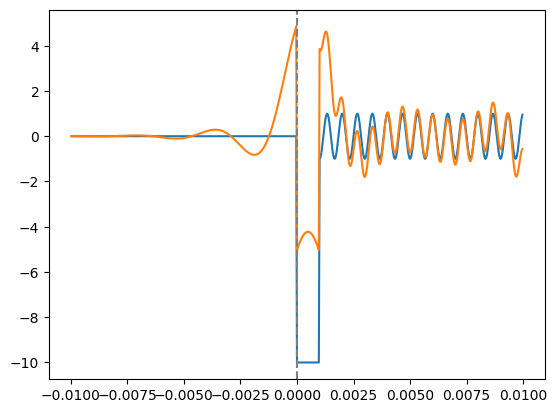

In [ ]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

# create a high-freq sinusoidal steady-state laser artifact, mimicking what we see:
rate = 30_000  # Hz
signal_freq = 1_500  # Hz
t = np.arange(0, 0.01, 1/rate)  # 10 ms duration
x = np.cos(2 * np.pi * signal_freq * t)  # Simulated signal

# create a baseline with no signal:
t = np.concatenate([(t * -1)[::-1], t[1:]])
x = np.concatenate([np.zeros_like(x[1:]), x])
midpoint = len(x) // 2

# add a large opto onset artifact (appears as large negative square after median-subtraction):
artifact_amplitude = 10 # au - multiple of sinusoid amplitude
artifact_samples = 0.001 * rate
x[midpoint: int(midpoint + artifact_samples)] = -artifact_amplitude 

# mimick settings for forward-backward high-pass filter applied by SpikeInterface:
coef = scipy.signal.iirfilter(
    5, 300, fs=rate, analog=False, btype="highpass", ftype="butter", output="sos"
)
f = scipy.signal.sosfiltfilt(coef, x)

plt.plot(t, x)
plt.plot(t, f)
plt.gca().axvline(0, color='grey', linestyle='--')

In [3]:
%load_ext autoreload
%autoreload 2
import opto_utils as utils
import polars as pl


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
filename = 'metrics'
df = (
    pl.scan_parquet(f's3://aind-scratch-data/dynamic-routing/optotagging/{filename}.parquet')
    # .select('_nwb_path', '_units_table_index', 'bin_pvalues', 'evoked_zscores')
    .filter(pl.col('_units_table_index') == 1261)
    .collect()
)
# df.explode('evoked_zscores').drop_nulls(), df.explode('bin_pvalues').unique('bin_pvalues').sort('bin_pvalues')
# df.with_columns(pl.col('evoked_zscores').list.max().alias('max_zscore'))
df

_units_table_index,_nwb_path,is_after_task,stim_name,location,duration,power,wavelength,bin_pvalues,evoked_zscores,first_spike_times,min_isis,unit_id
i64,str,bool,str,str,f64,f64,i64,list[f64],list[f64],list[f64],list[f64],str
1261,"""/data/dynamicrouting_datacube_…",true,"""square""","""probeD""",0.2,5.0,488,"[0.285831, 0.168528, … 0.168528]","[-0.517419, 0.477618, … 0.477618]","[null, 0.14308, … 0.166981]","[null, null, … null]","""733891_2024-09-19_B-106"""
1261,"""/data/dynamicrouting_datacube_…",true,"""square""","""probeE""",0.2,5.0,488,"[0.349785, 0.737741, … 0.662048]","[0.274124, 0.274124, … -0.704889]","[0.096735, 0.05108, … null]","[null, null, … null]","""744279_2025-01-14_F-310"""
1261,"""/data/dynamicrouting_datacube_…",true,"""square""","""probeF""",0.2,5.0,488,"[0.85083, 0.50387, … 0.729976]","[-0.444253, -0.444253, … -0.444253]","[null, null, … null]","[null, null, … null]","""703882_2024-04-22_E-395"""
1261,"""/data/dynamicrouting_datacube_…",false,"""square""","""probeD""",0.2,5.0,488,"[0.364079, 0.780881, … 0.146457]","[1.293588, -0.70269, … -0.70269]","[0.140118, null, … null]","[0.008167, null, … null]","""667252_2023-09-26_C-384"""
1261,"""/data/dynamicrouting_datacube_…",false,"""square""","""probeA""",0.01,5.0,488,"[0.50387, 0.50387, … 0.50387]","[-0.2, -0.2, … -0.2]","[null, null, … null]","[null, null, … null]","""681532_2023-10-16_C-242"""
…,…,…,…,…,…,…,…,…,…,…,…,…
1261,"""/data/dynamicrouting_datacube_…",true,"""square""","""probeA""",0.01,5.0,488,"[0.50387, 0.50387, … 0.50387]","[NaN, NaN, … NaN]","[null, null, … null]","[null, null, … null]","""668755_2023-08-31_C-80"""
1261,"""/data/dynamicrouting_datacube_…",false,"""square""","""probeA""",0.01,5.0,488,"[0.50387, 0.50387, … 0.50387]","[NaN, NaN, … NaN]","[null, null, … null]","[null, null, … null]","""666986_2023-08-17_C-390"""
1261,"""/data/dynamicrouting_datacube_…",false,"""square""","""probeB""",0.2,5.0,488,"[0.50387, 0.50387, … 0.50387]","[NaN, NaN, … NaN]","[null, null, … null]","[null, null, … null]","""733780_2024-08-29_C-579"""


In [ ]:
# df is one row per unique parameter set (incl 'is_after_task'), per unit
df = (
    # df
    pl.scan_parquet(f's3://aind-scratch-data/dynamic-routing/optotagging/metrics.parquet')
    ## for testing:
    # .filter(pl.col('_units_table_index') == 1261)
    .with_columns(
        utils.fraction_sig_bins().alias('fraction_sig_bins'),
        pl.col('evoked_zscores').list.max().alias('max_evoked_zscore'),
        pl.col('min_isis').list.mean().alias('mean_min_isi'),
        pl.col('min_isis').list.min().lt(0.0007).alias('artifactual_spikes'),
    )
    .with_columns(
        (
            pl.col('max_evoked_zscore').gt(2) 
            & pl.col('fraction_sig_bins').gt(0) 
            & ~pl.col('artifactual_spikes')
        ).alias('is_response'),
    )
    .group_by('_nwb_path', '_units_table_index')
    .agg(
        pl.col('unit_id').first(),
        pl.col('is_response').filter(pl.col('duration') == 0.01).any().alias('is_tagged')
    )
    .sort(['is_tagged', 'unit_id'], descending=True, nulls_last=True)
    .collect()
)
df.describe()
    

statistic,_nwb_path,_units_table_index,unit_id,is_tagged
str,str,f64,str,f64
"""count""","""233549""",233549.0,"""233549""",233549.0
"""null_count""","""0""",0.0,"""0""",0.0
"""mean""",null,1482.877349,null,0.005699
"""std""",null,998.700405,null,null
"""min""","""/data/dynamicrouting_datacube_…",0.0,"""660023_2023-08-09_A-0""",0.0
"""25%""",null,654.0,null,null
"""50%""",null,1350.0,null,null
"""75%""",null,2174.0,null,null
"""max""","""/data/dynamicrouting_datacube_…",4955.0,"""744279_2025-01-16_F-99""",1.0


In [4]:
import polars as pl

labels = (
    pl.read_parquet('s3://aind-scratch-data/dynamic-routing/optotagging/labels.parquet')
)
labels.describe()

statistic,unit_id,_nwb_path,_units_table_index,is_short_pulse_tagged,is_not_tagged,line
str,str,str,f64,f64,f64,str
"""count""","""583702""","""583702""",583702.0,256526.0,256526.0,"""573906"""
"""null_count""","""0""","""0""",0.0,327176.0,327176.0,"""9796"""
"""mean""",null,null,1389.911434,0.004888,0.089636,null
"""std""",null,null,982.637412,null,null,null
"""min""","""620263_2022-07-26_B-0""","""/data/dynamicrouting_datacube_…",0.0,0.0,0.0,"""pvalb"""
"""25%""",null,null,589.0,null,null,null
"""50%""",null,null,1228.0,null,null,null
"""75%""",null,null,2027.0,null,null,null
"""max""","""767172_2024-11-06_D-99""","""/data/dynamicrouting_datacube_…",5556.0,1.0,1.0,"""wt"""


In [28]:
import altair as alt

(
    labels.group_by('line').agg(
        pl.col('is_short_pulse_tagged').sum().alias('n_tagged'),
        pl.col('is_not_tagged').sum().alias('n_not_tagged'),
        pl.col('unit_id').count().alias('n_units'),
    )
    .unpivot(
        on=['n_tagged', 'n_not_tagged'],
        index=['line', 'n_units'],
        variable_name='metric',
        value_name='value',
    )
    .plot.bar(
        x='line',
        column='metric',
        y=alt.Y('value').scale(type='symlog'),
        color='line',
        tooltip=['line', 'metric', 'value', 'n_units'],
    )
)

alt.Chart(...)